# Обучение классических ML-моделей

In [ ]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/Users/n.mamashakirov/PycharmProjects/hseml-group-project-nurtilekmamashakirov-2')

from src.data.yambda_dataset import get_yambda_pandas
from src.data.utils import split_data_by_timestamp, get_ground_truth, add_counters_features, add_als_dot_product_features
from src.models.counters import EventCounter, ListeningTimeCounter
from src.models.matrix_factorizations import ALS

TRAIN_DATASET_PATH = '../data/datasets/train.parquet'
TEST_DATASET_PATH = '../data/datasets/test.parquet'

TARGET_BIN = 'target'

FEATURES = ['track_length_seconds', 
            'listen_events_counter', 
            'like_events_counter', 
            'dislike_events_counter', 
            'listen_time_counter', 
            'als_like_dot_product', 
            'als_listen_dot_product',
            'als_dislike_dot_product',
            'als_hybrid_dot_product']

TARGET = 'played_ratio_pct'

NEED_COLUMNS = FEATURES + [TARGET]

COUNTERS_PATH = "../data/features/counters.parquet"

USER_ALS_EMBEDDINGS_PATH = "../data/features/user-als-embeddings.parquet"
ITEM_ALS_EMBEDDINGS_PATH = "../data/features/item-als-embeddings.parquet"

/opt/anaconda3/envs/for_hw/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Фичи-инженеринг / Подготовка датасета

Подготовим сплит, отфильтруем всех холодных юзеров из теста

In [10]:
multi_events_df = get_yambda_pandas()

TRAIN_THRESHOLD = 0.8

train_df, test_df = split_data_by_timestamp(multi_events_df, TRAIN_THRESHOLD)
ground_truth = get_ground_truth(test_df=test_df, played_ratio_threshold=80.0)
train_users = set(train_df['uid'])
ground_truth = ground_truth[ground_truth.index.isin(train_users)]
test_df = test_df[test_df['uid'].isin(train_users)]

print(f"Размер тестовой выборки после фильтрации холодных юзеров: {test_df.shape[0]}")

Training set size: 38232359 rows
Testing set size: 9558090 rows
Размер тестовой выборки после фильтрации холодных юзеров: 9050667


Сохраним счетчики

In [11]:
COUNTERS_PATH = "../data/features/counters.parquet"

listen_event_counter = EventCounter("listen_events_counter")
listen_event_counter.fit(train_df, "listen")
listen_event_counter.save_counters(COUNTERS_PATH)

like_event_counter = EventCounter("like_events_counter")
like_event_counter.fit(train_df, "like")
like_event_counter.save_counters(COUNTERS_PATH)

dislike_event_counter = EventCounter("dislike_events_counter")
dislike_event_counter.fit(train_df, "dislike")
dislike_event_counter.save_counters(COUNTERS_PATH)

listen_time_counter = ListeningTimeCounter("listen_time_counter")
listen_time_counter.fit(train_df)
listen_time_counter.save_counters(COUNTERS_PATH)

Fitting EventCounter model for event 'listen'...
EventCounter model fitted successfully!
Saving EventCounter counters to ../data/features/counters.parquet...
EventCounter counters saved successfully as column 'listen_events_counter'!
Fitting EventCounter model for event 'like'...
EventCounter model fitted successfully!
Saving EventCounter counters to ../data/features/counters.parquet...
EventCounter counters saved successfully as column 'like_events_counter'!
Fitting EventCounter model for event 'dislike'...
EventCounter model fitted successfully!
Saving EventCounter counters to ../data/features/counters.parquet...
EventCounter counters saved successfully as column 'dislike_events_counter'!
Fitting ListeningTimeCounter model for event 'listen'...
ListeningTimeCounter model fitted successfully!
Saving ListeningTimeCounter counters to ../data/features/counters.parquet...
ListeningTimeCounter counters saved successfully as column 'listen_time_counter'!


Сохраним als-эмбеддинги

In [12]:
USER_ALS_EMBEDDINGS_PATH = "../data/features/user-als-embeddings.parquet"
ITEM_ALS_EMBEDDINGS_PATH = "../data/features/item-als-embeddings.parquet"

als_like = ALS("als_like", iterations=20)
als_like.fit(train_df, event_weights={"like": 1, "dislike": 0, "unlike": -1, "undislike": 0}, listen_weight=0)
als_like.save_embeddings(USER_ALS_EMBEDDINGS_PATH, ITEM_ALS_EMBEDDINGS_PATH)

als_listen = ALS("als_listen", iterations=20)
als_listen.fit(train_df, event_weights={"like": 1, "dislike": 0, "unlike": -1, "undislike": 0}, listen_weight=0.01)
als_listen.save_embeddings(USER_ALS_EMBEDDINGS_PATH, ITEM_ALS_EMBEDDINGS_PATH)

als_dislike = ALS("als_dislike", iterations=20)
als_dislike.fit(train_df, event_weights={"like": 0, "dislike": 1, "unlike": 0, "undislike": -1}, listen_weight=0)
als_dislike.save_embeddings(USER_ALS_EMBEDDINGS_PATH, ITEM_ALS_EMBEDDINGS_PATH)

als_hybrid = ALS("als_hybrid", iterations=20)
als_hybrid.fit(train_df, event_weights={"like": 1, "dislike": -1, "unlike": -1, "undislike": 1}, listen_weight=0.01)
als_hybrid.save_embeddings(USER_ALS_EMBEDDINGS_PATH, ITEM_ALS_EMBEDDINGS_PATH)

Preparing data for ALS model training with custom event weights...
Training ALS model...


100%|██████████| 20/20 [01:15<00:00,  3.75s/it]


ALS model trained successfully!
Saving user embeddings to ../data/features/user-als-embeddings.parquet...
User embeddings saved successfully for factorization: als_like
Saving item embeddings to ../data/features/item-als-embeddings.parquet...
Item embeddings saved successfully for factorization: als_like
Preparing data for ALS model training with custom event weights...
Training ALS model...


100%|██████████| 20/20 [01:32<00:00,  4.62s/it]


ALS model trained successfully!
Saving user embeddings to ../data/features/user-als-embeddings.parquet...
User embeddings saved successfully for factorization: als_listen
Saving item embeddings to ../data/features/item-als-embeddings.parquet...
Item embeddings saved successfully for factorization: als_listen
Preparing data for ALS model training with custom event weights...
Training ALS model...


100%|██████████| 20/20 [01:04<00:00,  3.23s/it]


ALS model trained successfully!
Saving user embeddings to ../data/features/user-als-embeddings.parquet...
User embeddings saved successfully for factorization: als_dislike
Saving item embeddings to ../data/features/item-als-embeddings.parquet...
Item embeddings saved successfully for factorization: als_dislike
Preparing data for ALS model training with custom event weights...
Training ALS model...


100%|██████████| 20/20 [01:32<00:00,  4.61s/it]


ALS model trained successfully!
Saving user embeddings to ../data/features/user-als-embeddings.parquet...
User embeddings saved successfully for factorization: als_hybrid
Saving item embeddings to ../data/features/item-als-embeddings.parquet...
Item embeddings saved successfully for factorization: als_hybrid


Сджойним датасеты со счетчиками

In [ ]:
counter_names = ['listen_events_counter', 'like_events_counter', 'dislike_events_counter', 'listen_time_counter']
als_names = ['als_like', 'als_listen', 'als_dislike', 'als_hybrid']

train_df_with_features = add_counters_features(train_df, counter_names, COUNTERS_PATH)
train_df_with_features = add_als_dot_product_features(train_df_with_features, als_names, USER_ALS_EMBEDDINGS_PATH, ITEM_ALS_EMBEDDINGS_PATH)

test_df_with_features = add_counters_features(test_df, counter_names, COUNTERS_PATH)
test_df_with_features = add_als_dot_product_features(test_df_with_features, als_names, USER_ALS_EMBEDDINGS_PATH, ITEM_ALS_EMBEDDINGS_PATH)

Размер исходного df_with_features: 2737MB
Вычисление скалярного произведения для разложения: als_like с использованием df.apply...
Загрузка эмбеддингов пользователей для als_like...
user_embeddings_df: 4MB
Загрузка эмбеддингов элементов для als_like...
item_embeddings_df: 384MB
user_embedding_map: 0MB
item_embedding_map: 40MB
factors: 0MB
df_with_features после скалярного произведения: 3029MB
Отображения эмбеддингов для als_like удалены из памяти.
Вычисление скалярного произведения для разложения: als_listen с использованием df.apply...
Загрузка эмбеддингов пользователей для als_listen...
user_embeddings_df: 4MB
Загрузка эмбеддингов элементов для als_listen...
item_embeddings_df: 384MB
user_embedding_map: 0MB
item_embedding_map: 40MB
factors: 0MB
df_with_features после скалярного произведения: 3321MB
Отображения эмбеддингов для als_listen удалены из памяти.
Вычисление скалярного произведения для разложения: als_dislike с использованием df.apply...
Загрузка эмбеддингов пользователей для

In [49]:
train_df_with_features.head()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type,listen_events_counter,like_events_counter,dislike_events_counter,listen_time_counter,als_like_dot_product,als_listen_dot_product,als_dislike_dot_product,als_hybrid_dot_product
0,468300,0,7400764,0,100.0,225.0,listen,295.0,4.0,NaN,20328.0,-1.067976e-15,0.763153,4.450704e-21,0.763998
1,347600,5,3415205,0,100.0,250.0,listen,480.0,15.0,NaN,32879.0,8.636960e-02,0.488905,-4.703235e-14,0.488386
2,942900,10,6728180,0,1.0,270.0,listen,5.0,1.0,NaN,21.0,3.212780e-04,0.011288,-2.181855e-14,0.011273
3,12700,15,8932363,0,100.0,245.0,listen,148.0,NaN,NaN,11082.0,3.186120e-14,0.179743,-4.778382e-14,0.180265
4,243500,15,5283544,1,100.0,195.0,listen,718.0,12.0,1.0,46536.0,2.877980e-03,0.035646,-3.589917e-15,0.036526


In [61]:
train_df_with_features = train_df_with_features[train_df_with_features['event_type'] == 'listen']
test_df_with_features = test_df_with_features[test_df_with_features['event_type'] == 'listen']

train_df_with_features.like_events_counter = train_df_with_features.like_events_counter.fillna(0)
train_df_with_features.listen_events_counter = train_df_with_features.listen_events_counter.fillna(0)
train_df_with_features.listen_time_counter = train_df_with_features.listen_time_counter.fillna(0)
train_df_with_features.dislike_events_counter = train_df_with_features.dislike_events_counter.fillna(0)

test_df_with_features.like_events_counter = test_df_with_features.like_events_counter.fillna(0)
test_df_with_features.listen_events_counter = test_df_with_features.listen_events_counter.fillna(0)
test_df_with_features.listen_time_counter = test_df_with_features.listen_time_counter.fillna(0)
test_df_with_features.dislike_events_counter = test_df_with_features.dislike_events_counter.fillna(0)

train_df_with_features = train_df_with_features[NEED_COLUMNS]
test_df_with_features = test_df_with_features[NEED_COLUMNS]

In [ ]:
train_df_with_features.to_parquet(TRAIN_DATASET_PATH)
test_df_with_features.to_parquet(TEST_DATASET_PATH)

### Аналитика фичей

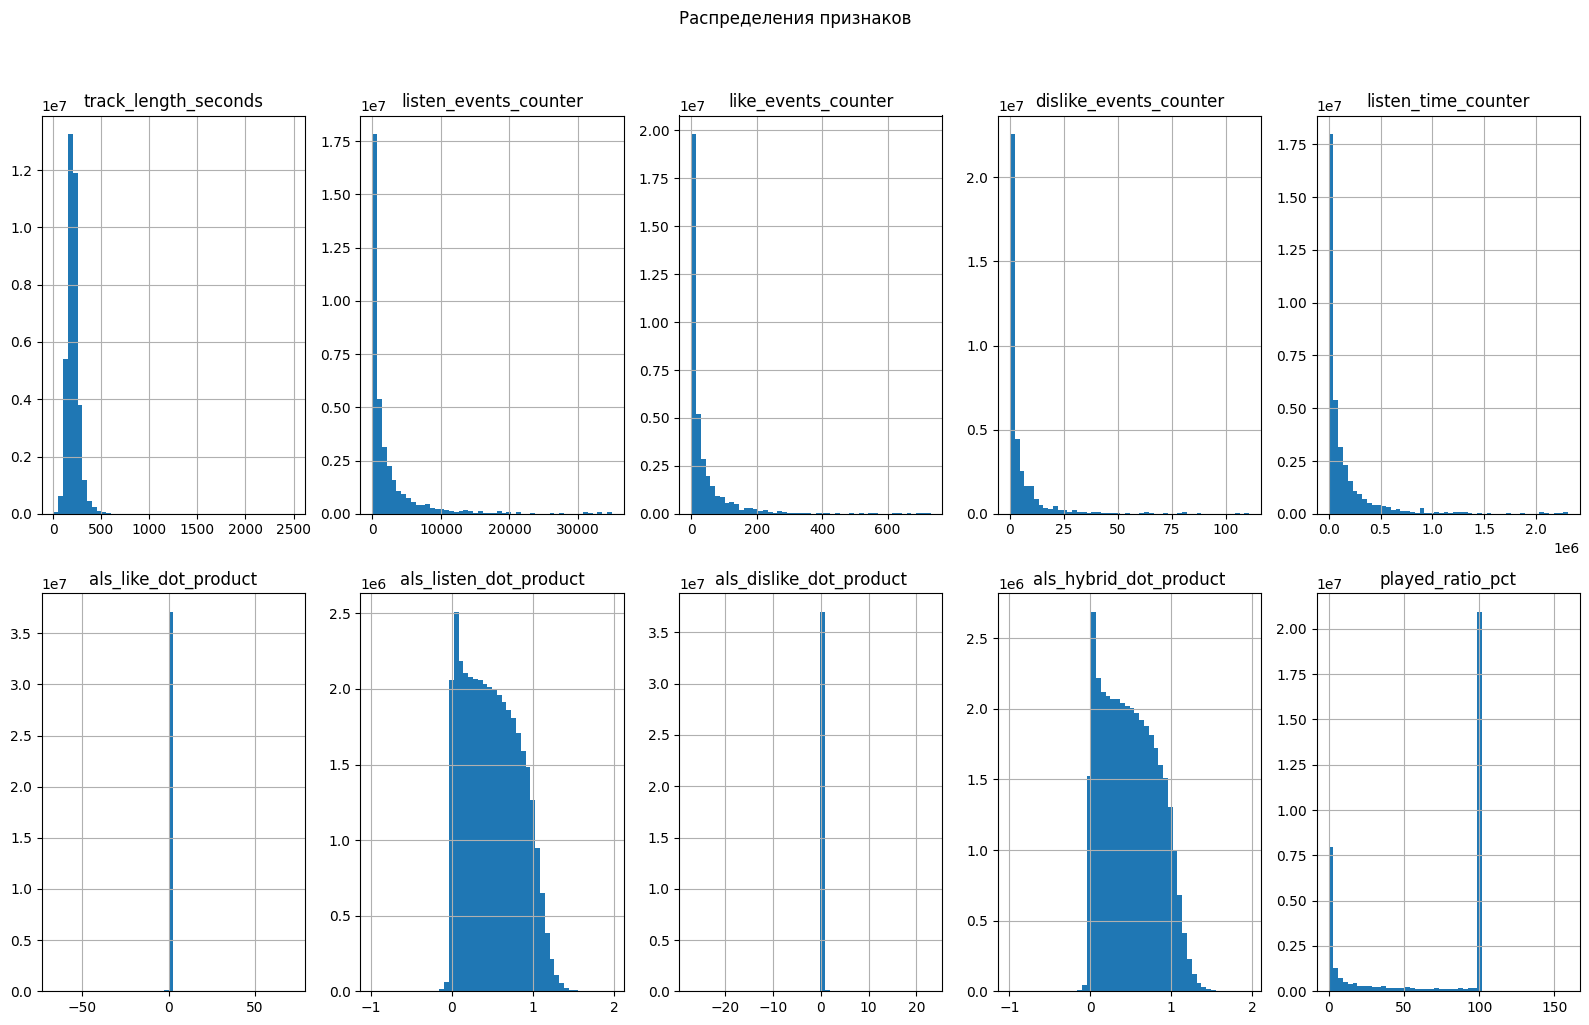

In [ ]:
train_df_with_features[FEATURES + [TARGET]].hist(bins=50, figsize=(16, 10), layout=(2, 5))
plt.suptitle('Распределения признаков', y=1.02)
plt.tight_layout()
plt.show()

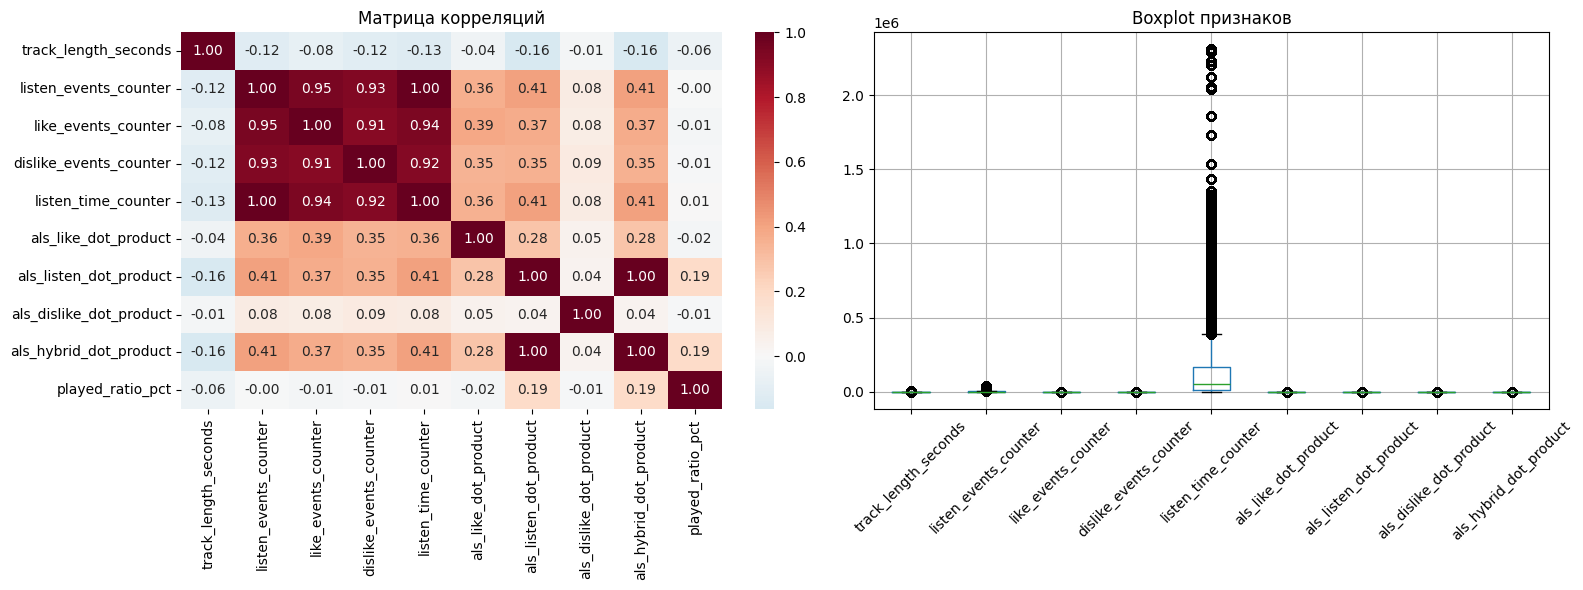

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(train_df_with_features[FEATURES + [TARGET]].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Матрица корреляций')

train_df_with_features[FEATURES].boxplot(ax=axes[1])
axes[1].set_title('Boxplot признаков')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

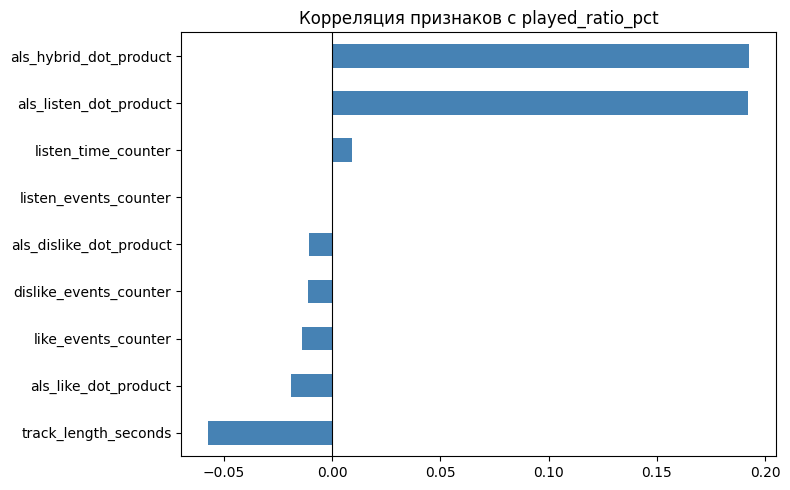

In [70]:
# Корреляция каждого признака с таргетом
train_df_with_features[FEATURES].corrwith(train_df_with_features[TARGET]).sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title(f'Корреляция признаков с {TARGET}')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Логистическая регрессия

In [3]:
train_df_with_features = pd.read_parquet(TRAIN_DATASET_PATH)
test_df_with_features = pd.read_parquet(TEST_DATASET_PATH)

train_df_with_features[TARGET_BIN] = (train_df_with_features[TARGET] > 0.8).astype(int)
test_df_with_features[TARGET_BIN] = (test_df_with_features[TARGET] > 0.8).astype(int)

X_train = train_df_with_features[FEATURES]
y_train = train_df_with_features[TARGET_BIN]
X_test = test_df_with_features[FEATURES]
y_test = test_df_with_features[TARGET_BIN]

train_df_with_features.head()

,track_length_seconds,listen_events_counter,like_events_counter,dislike_events_counter,listen_time_counter,als_like_dot_product,als_listen_dot_product,als_dislike_dot_product,als_hybrid_dot_product,played_ratio_pct,target
0,225.0,295.0,4.0,0.0,20328.0,-1.067976e-15,0.763153,4.450704e-21,0.763998,100.0,1
1,250.0,480.0,15.0,0.0,32879.0,8.636960e-02,0.488905,-4.703235e-14,0.488386,100.0,1
2,270.0,5.0,1.0,0.0,21.0,3.212780e-04,0.011288,-2.181855e-14,0.011273,1.0,1
3,245.0,148.0,0.0,0.0,11082.0,3.186120e-14,0.179743,-4.778382e-14,0.180265,100.0,1
4,195.0,718.0,12.0,1.0,46536.0,2.877980e-03,0.035646,-3.589917e-15,0.036526,100.0,1


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

              precision    recall  f1-score   support

           0       0.15      0.00      0.01    627563
           1       0.93      1.00      0.96   8176868

    accuracy                           0.93   8804431
   macro avg       0.54      0.50      0.48   8804431
weighted avg       0.87      0.93      0.89   8804431

ROC-AUC: 0.5818


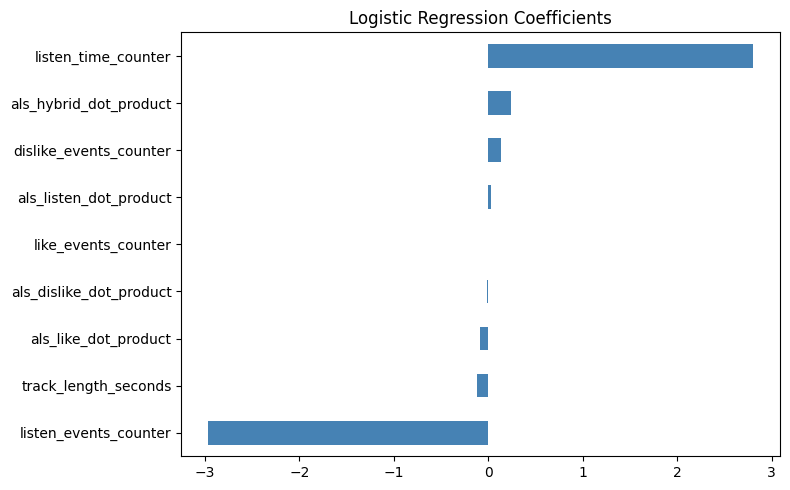

In [5]:
pd.Series(lr.coef_[0], index=FEATURES).sort_values().plot(
    kind='barh', figsize=(8, 5), color='steelblue'
)
plt.title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

### Градиентный бустинг (СatBoost) под бинарный таргет

In [6]:
from catboost import CatBoostClassifier

cb_clf = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=6,
                             loss_function='Logloss', random_seed=42, verbose=100)

cb_clf.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)

y_pred_cb = cb_clf.predict(X_test)
y_proba_cb = cb_clf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_cb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_cb):.4f}")

0:	learn: 0.6578498	test: 0.6589406	best: 0.6589406 (0)	total: 1.04s	remaining: 1m 43s
99:	learn: 0.2577535	test: 0.2695444	best: 0.2685810 (89)	total: 45.4s	remaining: 0us

bestTest = 0.2685809767
bestIteration = 89

Shrink model to first 90 iterations.
              precision    recall  f1-score   support

           0       0.26      0.00      0.00    627563
           1       0.93      1.00      0.96   8176868

    accuracy                           0.93   8804431
   macro avg       0.59      0.50      0.48   8804431
weighted avg       0.88      0.93      0.89   8804431

ROC-AUC: 0.5884


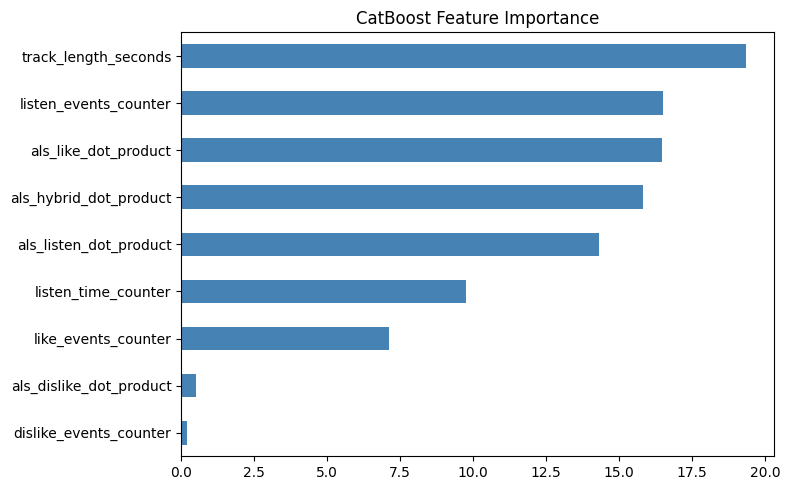

In [7]:
pd.Series(cb_clf.get_feature_importance(), index=FEATURES).sort_values().plot(
    kind='barh', figsize=(8, 5), color='steelblue'
)
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.show()

Увидели, что на метрике классификации CatBoost выигрывает по ROC-AUC-метрике. Будет валидно использовать его для двух-этапного ранкера на стадии ранжирования, чтобы замерить метрику ранжирования

In [ ]:
cb_clf.feature_names_
cb_clf.fea

['track_length_seconds',
 'listen_events_counter',
 'like_events_counter',
 'dislike_events_counter',
 'listen_time_counter',
 'als_like_dot_product',
 'als_listen_dot_product',
 'als_dislike_dot_product',
 'als_hybrid_dot_product']

### Оценка метрик ранжирования

In [30]:
from src.models.rankers import TwoStageRanker

track_length_df = train_df[['item_id', 'track_length_seconds']].drop_duplicates('item_id').reset_index(drop=True)
als_recommenders = {"als_like": als_like, "als_listen": als_listen, "als_dislike": als_dislike, "als_hybrid": als_hybrid}
counter_recommenders = {
    "listen_events_counter": listen_event_counter,
    "like_events_counter": like_event_counter,
    "listen_time_counter": listen_time_counter,
    "dislike_events_counter": dislike_event_counter
}
all_recommenders = counter_recommenders | als_recommenders

user_embeddings_df = pd.read_parquet(USER_ALS_EMBEDDINGS_PATH)
item_embeddings_df = pd.read_parquet(ITEM_ALS_EMBEDDINGS_PATH)

ranker = TwoStageRanker("catboost_ranker")
ranker.fit(
    recommenders=all_recommenders,
    catboost_model=cb_clf,
    feature_names=FEATURES,
    counter_names=['listen_events_counter', 'like_events_counter', 'listen_time_counter', 'dislike_events_counter'],
    counters_path=COUNTERS_PATH,
    user_embeddings_df=user_embeddings_df,
    item_embeddings_df=item_embeddings_df,
    track_length_df=track_length_df
)

Reading counters from parquet...
Counters loaded: ['listen_events_counter', 'like_events_counter', 'listen_time_counter', 'dislike_events_counter']
Embedding dot products to compute: ['als_listen', 'als_like', 'als_dislike', 'als_hybrid']
TwoStageRanker is ready!


In [31]:
from src.metrics.evaluators import evaluate_recommenders

evaluate_recommenders({"two_stage": ranker}, ground_truth=ground_truth)

Evaluating 'two_stage'...
Generating candidates...
  Generating candidates from 'listen_events_counter'...
  Generating candidates from 'like_events_counter'...
  Generating candidates from 'listen_time_counter'...
  Generating candidates from 'dislike_events_counter'...
  Generating candidates from 'als_like'...
  Generating candidates from 'als_listen'...
  Generating candidates from 'als_dislike'...
  Generating candidates from 'als_hybrid'...
  Total unique candidates: 1,796,416
Building features...
  precision@10 = 0.1040
  hit_rate@10  = 0.4538
  map@10       = 0.0510
  ndcg@10      = 0.1038


,precision@10,hit_rate@10,map@10,ndcg@10
uid,,,,
two_stage,0.103983,0.453841,0.050991,0.103849


Вывод:

В данной работе реализовали двух-этапную рекомендатулеьную систему с кандидатогенерацией и финальным ранжированием.